In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/london_merged.csv")

# First 5 rows
display(df.head())

print("Dataset shape:", df.shape)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


Dataset shape: (17414, 10)


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Convert timestamp into datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("\nData types:")
print(df.dtypes)

Missing values:
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Duplicate rows: 0

Data types:
timestamp       datetime64[ns]
cnt                      int64
t1                     float64
t2                     float64
hum                    float64
wind_speed             float64
weather_code           float64
is_holiday             float64
is_weekend             float64
season                 float64
dtype: object


In [5]:
# Date/time features
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.month_name()
df["day"] = df["timestamp"].dt.day
df["day_name"] = df["timestamp"].dt.day_name()
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

# Convert 0/1 fields to integers
df["is_holiday"] = df["is_holiday"].astype(int)
df["is_weekend"] = df["is_weekend"].astype(int)
df["season"] = df["season"].astype(int)
df["weather_code"] = df["weather_code"].astype(int)

display(df.head())

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,year,month,month_name,day,day_name,hour,date
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3,0,1,3,2015,1,January,4,Sunday,0,2015-01-04
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1,0,1,3,2015,1,January,4,Sunday,1,2015-01-04
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1,0,1,3,2015,1,January,4,Sunday,2,2015-01-04
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1,0,1,3,2015,1,January,4,Sunday,3,2015-01-04
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1,0,1,3,2015,1,January,4,Sunday,4,2015-01-04


In [6]:
# Season names
season_map = {
    0: "Spring",
    1: "Summer",
    2: "Autumn",
    3: "Winter"
}

df["season_name"] = df["season"].map(season_map)

# Weather names
weather_map = {
    1: "Clear",
    2: "Few Clouds",
    3: "Broken Clouds",
    4: "Cloudy",
    7: "Rain",
    10: "Rain + Thunder",
    26: "Snowfall"
}

df["weather_name"] = df["weather_code"].map(weather_map)

display(df[[
    "timestamp", "cnt", "t1", "hum",
    "hour", "day_name", "season_name", "weather_name"
]].head())

,timestamp,cnt,t1,hum,hour,day_name,season_name,weather_name
0,2015-01-04 00:00:00,182,3.0,93.0,0,Sunday,Winter,Broken Clouds
1,2015-01-04 01:00:00,138,3.0,93.0,1,Sunday,Winter,Clear
2,2015-01-04 02:00:00,134,2.5,96.5,2,Sunday,Winter,Clear
3,2015-01-04 03:00:00,72,2.0,100.0,3,Sunday,Winter,Clear
4,2015-01-04 04:00:00,47,2.0,93.0,4,Sunday,Winter,Clear


In [7]:
print(df.describe().round(2))

                           timestamp       cnt        t1        t2       hum  \
count                          17414  17414.00  17414.00  17414.00  17414.00   
mean   2016-01-03 22:31:00.571953664   1143.10     12.47     11.52     72.32   
min              2015-01-04 00:00:00      0.00     -1.50     -6.00     20.50   
25%              2015-07-04 20:15:00    257.00      8.00      6.00     63.00   
50%              2016-01-03 15:30:00    844.00     12.50     12.50     74.50   
75%              2016-07-04 15:45:00   1671.75     16.00     16.00     83.00   
max              2017-01-03 23:00:00   7860.00     34.00     34.00    100.00   
std                              NaN   1085.11      5.57      6.62     14.31   

       wind_speed  weather_code  is_holiday  is_weekend    season      year  \
count    17414.00      17414.00    17414.00    17414.00  17414.00  17414.00   
mean        15.91          2.72        0.02        0.29      1.49   2015.51   
min          0.00          1.00        0.0

In [8]:
print("Average rentals:", round(df["cnt"].mean(), 2))
print("Median rentals:", round(df["cnt"].median(), 2))
print("Maximum rentals:", df["cnt"].max())
print("Minimum rentals:", df["cnt"].min())

Average rentals: 1143.1
Median rentals: 844.0
Maximum rentals: 7860
Minimum rentals: 0


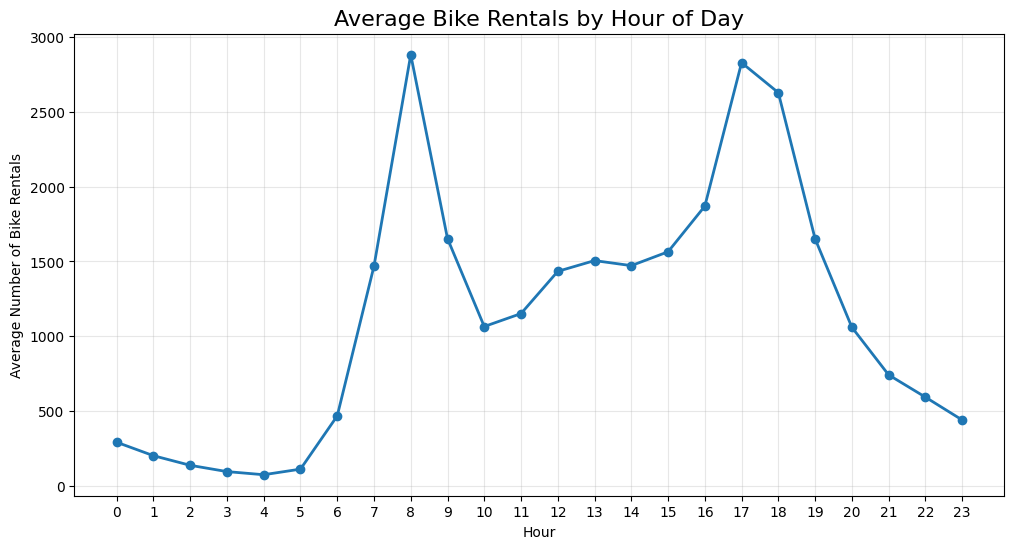

In [9]:
hourly = df.groupby("hour")["cnt"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o",
    linewidth=2
)

plt.title("Average Bike Rentals by Hour of Day", fontsize=16)
plt.xlabel("Hour")
plt.ylabel("Average Number of Bike Rentals")
plt.xticks(range(0,24))

plt.grid(alpha=0.3)
plt.show()

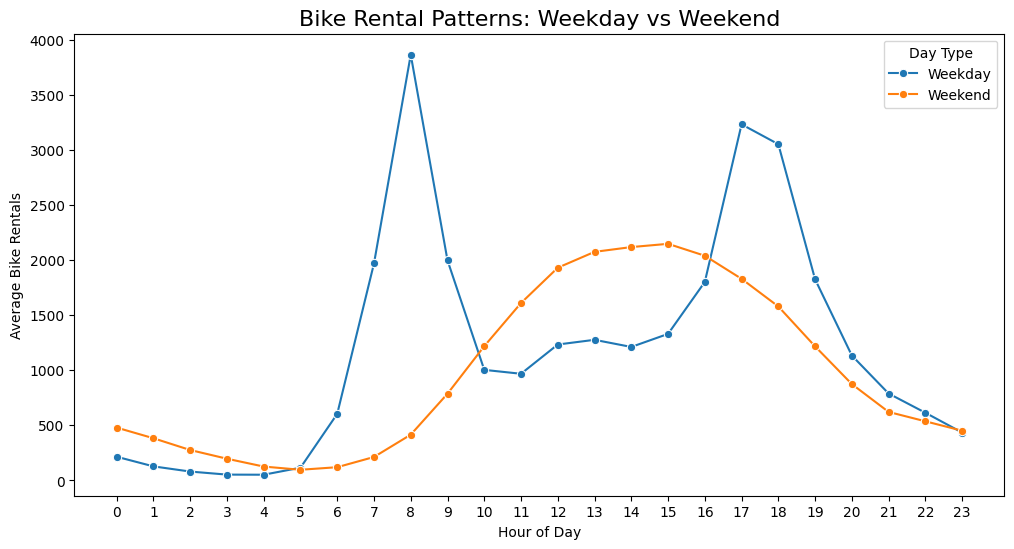

In [10]:
hour_weekend = df.groupby(
    ["hour", "is_weekend"]
)["cnt"].mean().reset_index()

hour_weekend["Day Type"] = hour_weekend["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hour_weekend,
    x="hour",
    y="cnt",
    hue="Day Type",
    marker="o"
)

plt.title("Bike Rental Patterns: Weekday vs Weekend", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Rentals")
plt.xticks(range(0,24))
plt.show()

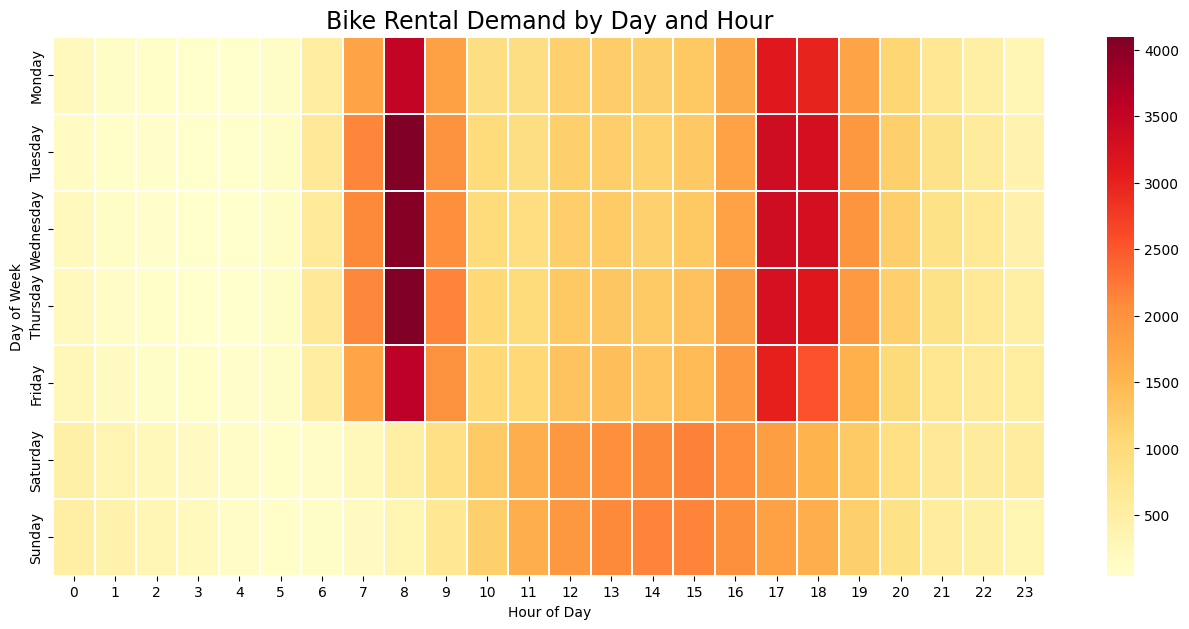

In [11]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = df.pivot_table(
    values="cnt",
    index="day_name",
    columns="hour",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(16,7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3
)

plt.title("Bike Rental Demand by Day and Hour", fontsize=17)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

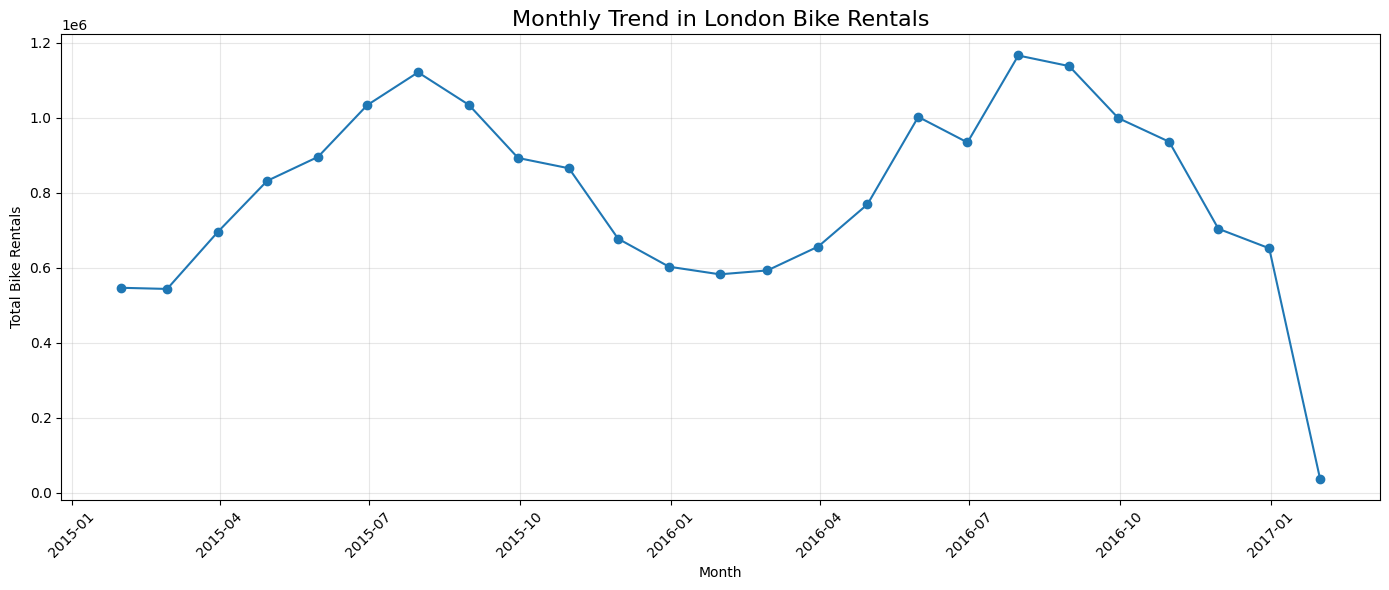

In [12]:
monthly = (
    df.set_index("timestamp")
      .resample("ME")["cnt"]
      .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Monthly Trend in London Bike Rentals", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Bike Rentals")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

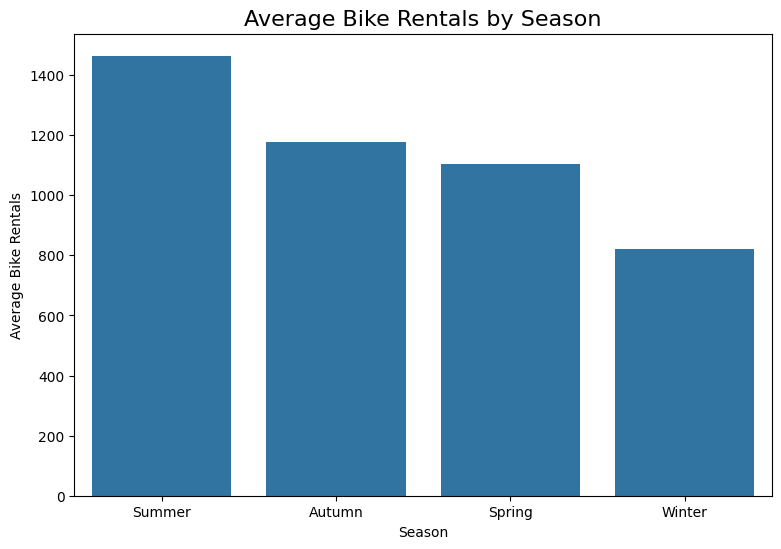

,season_name,cnt
0,Summer,1464.465238
1,Autumn,1178.954218
2,Spring,1103.831589
3,Winter,821.729099


In [13]:
season_avg = (
    df.groupby("season_name")["cnt"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9,6))

sns.barplot(
    data=season_avg,
    x="season_name",
    y="cnt"
)

plt.title("Average Bike Rentals by Season", fontsize=16)
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")

plt.show()

display(season_avg)

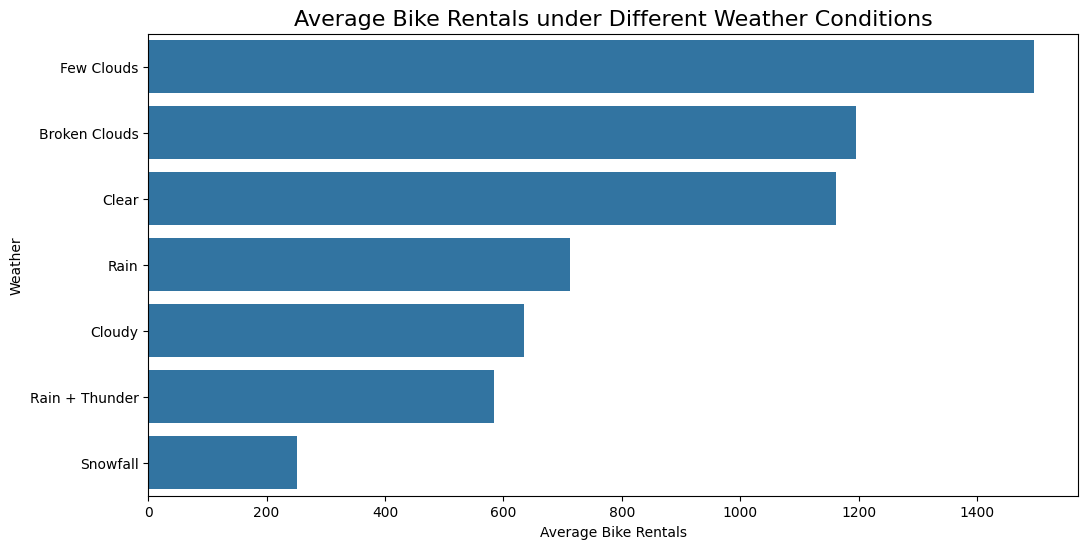

,weather_name,cnt
0,Few Clouds,1496.177491
1,Broken Clouds,1195.124472
2,Clear,1162.088943
3,Rain,712.966371
4,Cloudy,635.230874
5,Rain + Thunder,583.428571
6,Snowfall,250.850000


In [14]:
weather_avg = (
    df.groupby("weather_name")["cnt"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=weather_avg,
    x="cnt",
    y="weather_name"
)

plt.title("Average Bike Rentals under Different Weather Conditions", fontsize=16)
plt.xlabel("Average Bike Rentals")
plt.ylabel("Weather")

plt.show()

display(weather_avg)

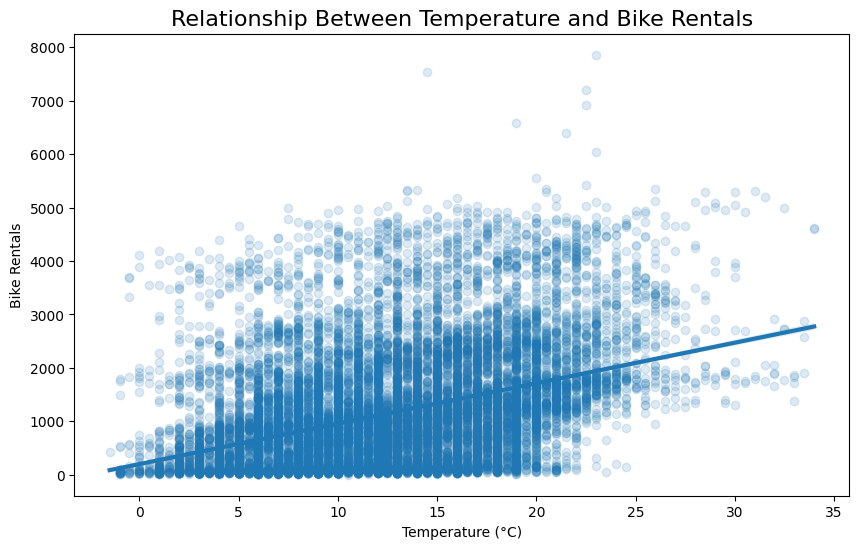

In [15]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="t1",
    y="cnt",
    scatter_kws={"alpha": 0.15},
    line_kws={"linewidth": 3}
)

plt.title("Relationship Between Temperature and Bike Rentals", fontsize=16)
plt.xlabel("Temperature (°C)")
plt.ylabel("Bike Rentals")

plt.show()

In [16]:
temp_correlation = df["t1"].corr(df["cnt"])

print(
    "Correlation between temperature and bike rentals:",
    round(temp_correlation, 3)
)

Correlation between temperature and bike rentals: 0.389


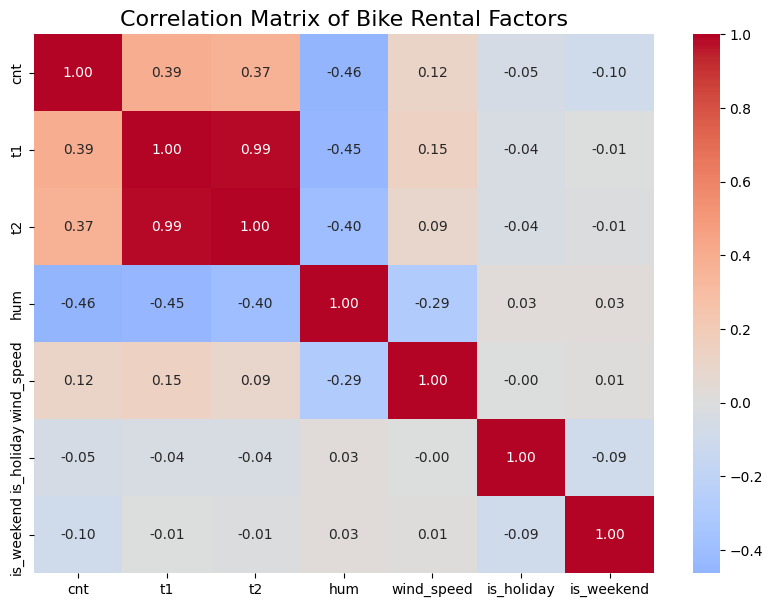

In [17]:
correlation_columns = [
    "cnt",
    "t1",
    "t2",
    "hum",
    "wind_speed",
    "is_holiday",
    "is_weekend"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Bike Rental Factors", fontsize=16)

plt.show()

In [18]:
print("Temperature:", round(df["cnt"].corr(df["t1"]), 3))
print("Humidity:", round(df["cnt"].corr(df["hum"]), 3))

Temperature: 0.389
Humidity: -0.463


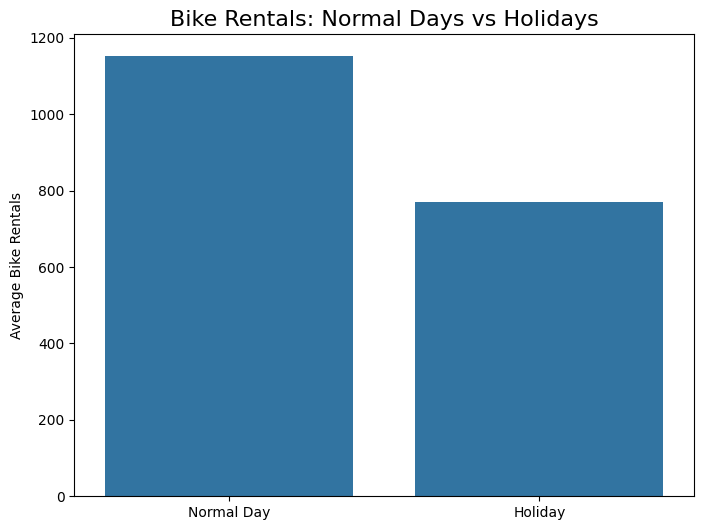

In [19]:
holiday_avg = df.groupby("is_holiday")["cnt"].mean().reset_index()

holiday_avg["Day Type"] = holiday_avg["is_holiday"].map({
    0: "Normal Day",
    1: "Holiday"
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=holiday_avg,
    x="Day Type",
    y="cnt"
)

plt.title("Bike Rentals: Normal Days vs Holidays", fontsize=16)
plt.xlabel("")
plt.ylabel("Average Bike Rentals")

plt.show()

In [20]:
df.to_csv(
    "london_bike_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
